# Machine Learning — Klasifikasi Kelayakan Kredit UMKM

Notebook ini mengimplementasikan pipeline end-to-end sesuai flowchart yang telah dirancang:

| Fase | Tahapan |
|------|--------|
| 1 | Data Understanding & EDA |
| 2 | Data Cleaning |
| 3 | Feature Engineering & Encoding |
| 4 | Train / Validation / Test Split |
| 5 | Model Selection & Training |
| 6 | Evaluasi Model |
| 7 | Hyperparameter Tuning |
| 8 | Explainability & Threshold Tuning |
| 9 | Packaging & Deployment |

---
## Cell 0 — Import library

Mengimpor semua library yang dibutuhkan untuk seluruh pipeline.

In [1]:
# ── Standar ──────────────────────────────────────────────────────
import warnings
import os
import joblib
import json

warnings.filterwarnings('ignore')

# ── Data ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisasi ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Model ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Evaluasi ──────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── Explainability ────────────────────────────────────────────────
import shap

print('✅  Semua library berhasil diimpor.')
print(f'    pandas  {pd.__version__}  |  numpy  {np.__version__}')

✅  Semua library berhasil diimpor.
    pandas  2.3.3  |  numpy  2.4.4


---
## Cell 1 — Load data

Membaca file CSV dan menampilkan gambaran awal dataset.

In [2]:
# ── Sesuaikan path jika file ada di folder lain ───────────────────
CSV_PATH = 'umkm_kredit_training_data.csv'

df_raw = pd.read_csv(CSV_PATH)

print(f'Jumlah baris   : {df_raw.shape[0]:,}')
print(f'Jumlah kolom   : {df_raw.shape[1]}')
print(f'Kolom          : {list(df_raw.columns)}')
print()
df_raw.head(3)

Jumlah baris   : 1,000
Jumlah kolom   : 34
Kolom          : ['id_pengajuan', 'nik', 'nomor_nib', 'kota', 'kbli_kode', 'kbli_deskripsi', 'skala_usaha', 'jenis_kur', 'lama_usaha_bulan', 'modal_usaha', 'plafon_diajukan', 'tenor_bulan', 'jumlah_tanggungan', 'ada_npwp', 'ada_bpjs_tk', 'total_pendapatan_bulanan', 'hpp_bulanan', 'laba_kotor_bulanan', 'biaya_operasional_bulanan', 'rata_laba_bersih_bulanan', 'rata_saldo_harian', 'total_kredit_3bln', 'total_debit_3bln', 'kolektibilitas_slik', 'total_kredit_aktif_slik', 'jumlah_fasilitas_slik', 'status_blacklist', 'kredit_lunas_sebelumnya', 'ada_agunan', 'jenis_agunan', 'nilai_agunan', 'rasio_agunan_terhadap_plafon', 'dti_ratio', 'label_kelayakan']



,id_pengajuan,nik,nomor_nib,kota,kbli_kode,kbli_deskripsi,skala_usaha,jenis_kur,lama_usaha_bulan,modal_usaha,...,total_kredit_aktif_slik,jumlah_fasilitas_slik,status_blacklist,kredit_lunas_sebelumnya,ada_agunan,jenis_agunan,nilai_agunan,rasio_agunan_terhadap_plafon,dti_ratio,label_kelayakan
0,bdfab8ea-1839-42b0-ae4b-991efb4a779f,3786743862513791,3640576573006,Jakarta,49431,Angkutan barang,kecil,kecil,79,697350443,...,36226302,4,Tidak,1,Ya,SHGB,1019122805,2.43,0.2351,Disetujui dengan syarat tambahan
1,a64fa5fb-a1ba-47e5-9c80-4677da5ad7da,6087067367908300,1239855650218,Denpasar,1111,Pertanian padi,mikro,mikro,64,116918877,...,6904334,2,Tidak,2,Ya,SHGB,34171151,1.56,0.2344,Disetujui langsung
2,835064cb-7fb7-4bb9-822d-0e9ccb5a98a3,6371526429654642,8918278954142,Bekasi,56101,Restoran dan rumah makan,kecil,kecil,94,2020562302,...,32902877,2,Tidak,3,Ya,SHGB,817975410,1.67,0.2039,Disetujui langsung


---
## Cell 2 — Fase 1: Data Understanding & EDA

Tujuan: memahami distribusi data, proporsi label, dan hubungan antar fitur **sebelum** melakukan perubahan apapun.

Yang diperiksa:
- Tipe data dan missing values
- Distribusi label (ground truth)
- Statistik deskriptif fitur numerik
- Distribusi fitur-fitur kunci

═══════════════════════════════════════════════════════
TIPE DATA & MISSING VALUES
═══════════════════════════════════════════════════════
Tidak ada missing values.

═══════════════════════════════════════════════════════
DISTRIBUSI LABEL (label_kelayakan)
═══════════════════════════════════════════════════════
label_kelayakan
Disetujui dengan syarat tambahan    200
Disetujui langsung                  200
Ditolak otomatis                    200
Perlu tinjauan komite               200
Perlu perbaikan profil              200



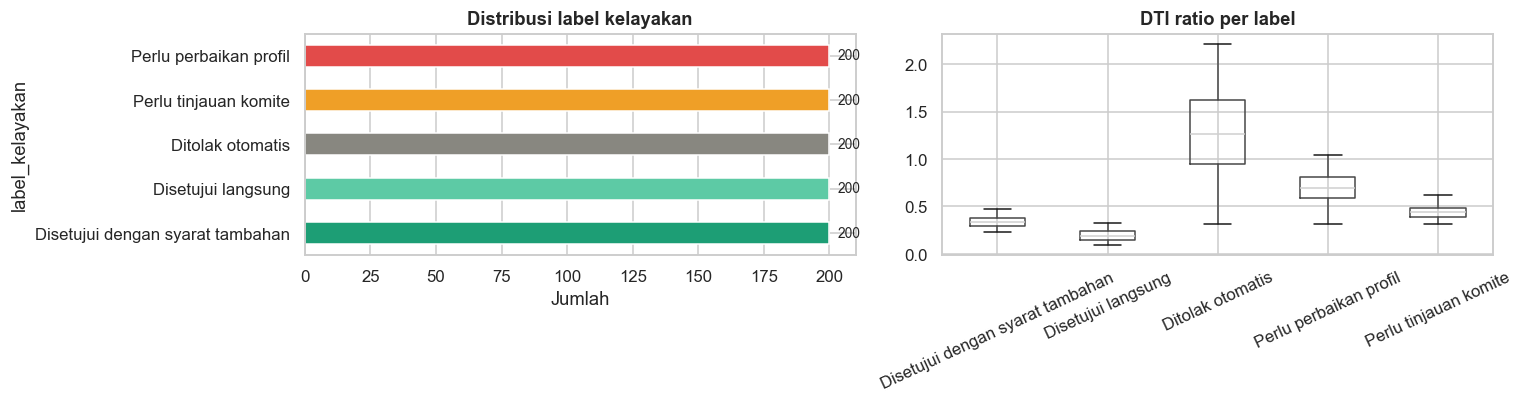

In [4]:
# ── 1a. Tipe data & missing values ───────────────────────────────
print('═' * 55)
print('TIPE DATA & MISSING VALUES')
print('═' * 55)
info = pd.DataFrame({
    'dtype'   : df_raw.dtypes,
    'non_null': df_raw.notna().sum(),
    'null'    : df_raw.isna().sum(),
    'null_%'  : (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})
print(info[info['null'] > 0].to_string() if info['null'].sum() > 0 else 'Tidak ada missing values.')
print()

# ── 1b. Distribusi label ─────────────────────────────────────────
print('═' * 55)
print('DISTRIBUSI LABEL (label_kelayakan)')
print('═' * 55)
label_dist = df_raw['label_kelayakan'].value_counts()
print(label_dist.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart distribusi label
colors = ['#E24B4A','#EF9F27','#888780','#5DCAA5','#1D9E75']
label_dist.plot(kind='barh', ax=axes[0], color=colors[::-1])
axes[0].set_title('Distribusi label kelayakan', fontweight='bold')
axes[0].set_xlabel('Jumlah')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', fontsize=9)

# Distribusi DTI ratio per label
label_order = ['Ditolak otomatis','Perlu perbaikan profil',
               'Perlu tinjauan komite','Disetujui dengan syarat tambahan',
               'Disetujui langsung']
df_raw.boxplot(column='dti_ratio', by='label_kelayakan',
               ax=axes[1])
axes[1].set_title('DTI ratio per label', fontweight='bold')
axes[1].set_xlabel('')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [5]:
# ── 1c. Statistik deskriptif fitur numerik utama ─────────────────
NUMERIC_KEY = [
    'lama_usaha_bulan','plafon_diajukan','tenor_bulan',
    'rata_laba_bersih_bulanan','rata_saldo_harian',
    'dti_ratio','kolektibilitas_slik','rasio_agunan_terhadap_plafon',
    'kredit_lunas_sebelumnya','total_kredit_aktif_slik'
]
df_raw[NUMERIC_KEY].describe().round(2)

,lama_usaha_bulan,plafon_diajukan,tenor_bulan,rata_laba_bersih_bulanan,rata_saldo_harian,dti_ratio,kolektibilitas_slik,rasio_agunan_terhadap_plafon,kredit_lunas_sebelumnya,total_kredit_aktif_slik
count,1000.00,1.000000e+03,1000.00,1.000000e+03,1.000000e+03,1000.00,1000.00,1000.00,1000.00,1.000000e+03
mean,57.08,2.438534e+08,31.61,2.653076e+07,5.711183e+07,0.60,2.33,0.95,0.56,9.233032e+07
std,55.88,6.383744e+08,14.11,8.442169e+07,1.863570e+08,0.44,1.19,0.94,0.86,1.087598e+08
min,1.00,1.074525e+06,12.00,1.000000e+05,1.000000e+05,0.09,1.00,0.00,0.00,0.000000e+00
25%,17.00,2.219492e+07,24.00,1.390830e+06,1.392653e+06,0.30,1.00,0.00,0.00,1.535634e+07
50%,35.00,4.152186e+07,36.00,3.912913e+06,4.619582e+06,0.44,2.00,1.20,0.00,5.772788e+07
75%,76.00,2.257734e+08,36.00,1.543502e+07,2.875286e+07,0.77,3.00,1.84,1.00,1.280486e+08
max,240.00,4.589182e+09,60.00,1.028392e+09,1.717001e+09,2.22,5.00,2.50,3.00,4.961300e+08


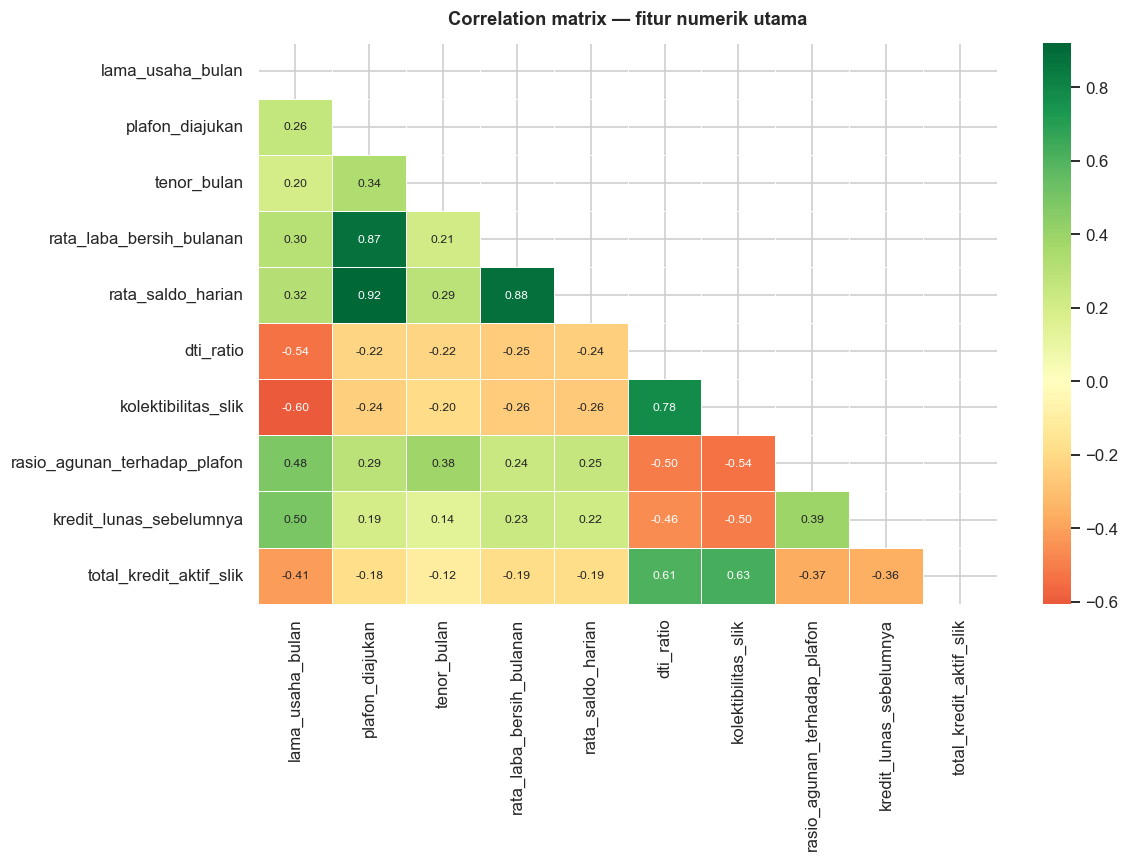

In [6]:
# ── 1d. Heatmap korelasi fitur numerik ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
corr = df_raw[NUMERIC_KEY].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation matrix — fitur numerik utama', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

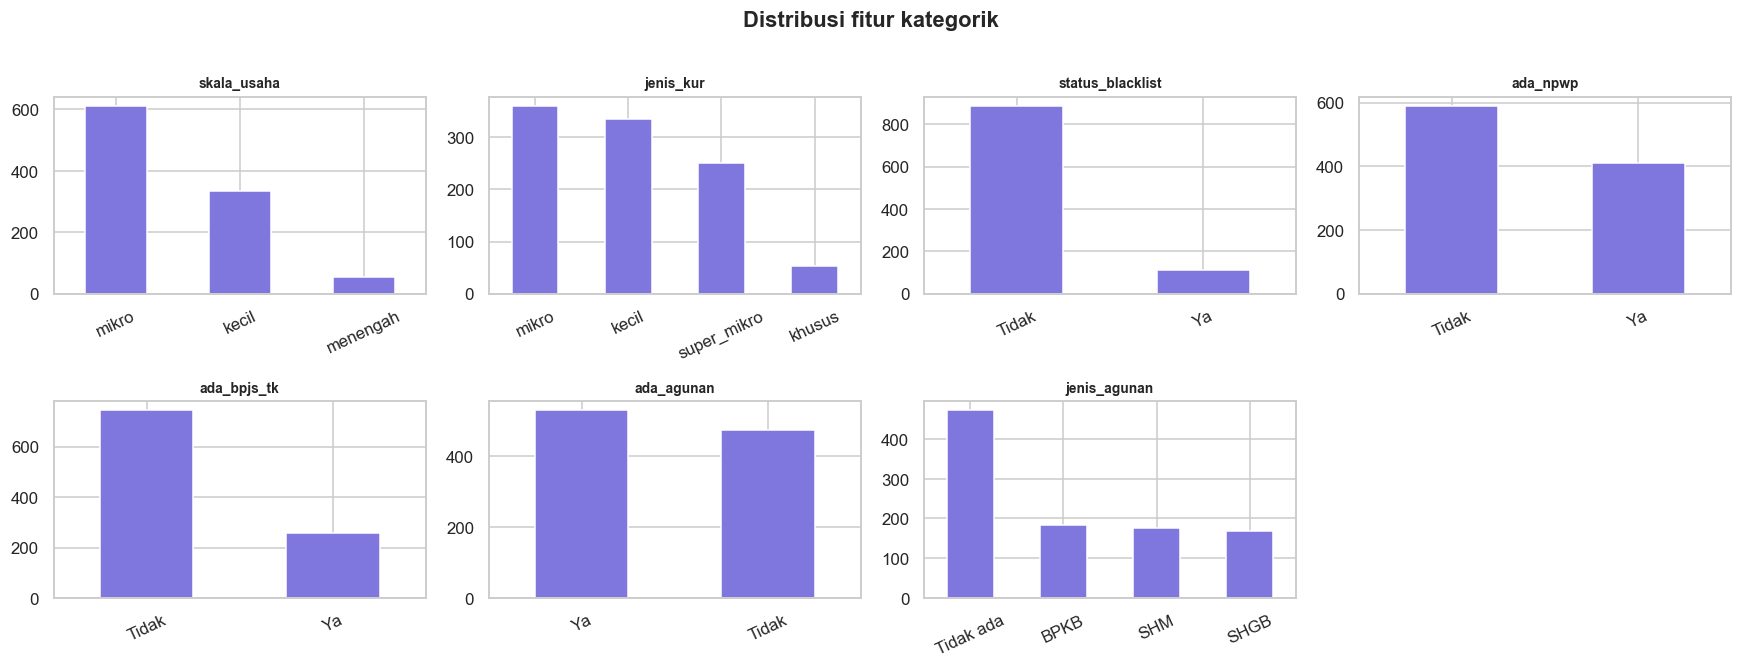

In [7]:
# ── 1e. Distribusi fitur kategorik ───────────────────────────────
CAT_COLS = ['skala_usaha','jenis_kur','status_blacklist',
            'ada_npwp','ada_bpjs_tk','ada_agunan','jenis_agunan']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    vc = df_raw[col].value_counts()
    vc.plot(kind='bar', ax=axes[i], color='#7F77DD', edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Distribusi fitur kategorik', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Cell 3 — Fase 2: Data Cleaning

Mengikuti langkah 2a–2d dari flowchart:
- **2a** Handle missing values
- **2b** Hapus duplikat & validasi konsistensi
- **2c** Cap outlier (bukan hapus) dengan metode IQR
- **2d** Konversi kolom Ya/Tidak menjadi boolean integer 0/1

In [8]:
df = df_raw.copy()

# ── 2a. Handle missing values ────────────────────────────────────
# nilai_agunan = 0 jika tidak ada agunan (logis, bukan imputasi)
df['nilai_agunan'] = df['nilai_agunan'].fillna(0)
df['rasio_agunan_terhadap_plafon'] = df['rasio_agunan_terhadap_plafon'].fillna(0)

null_remaining = df.isna().sum()
print('Missing values setelah penanganan:')
print(null_remaining[null_remaining > 0].to_string() 
      if null_remaining.sum() > 0 else '  Tidak ada.')

# ── 2b. Duplikat & validasi konsistensi ──────────────────────────
n_dup = df.duplicated(subset='id_pengajuan').sum()
print(f'\nDuplikat id_pengajuan : {n_dup}')
df = df.drop_duplicates(subset='id_pengajuan')

# Validasi: laba_kotor harus = pendapatan - hpp
check = (df['laba_kotor_bulanan'] - 
         (df['total_pendapatan_bulanan'] - df['hpp_bulanan'])).abs()
n_inconsistent = (check > 1000).sum()   # toleransi Rp 1.000 pembulatan
print(f'Baris laba_kotor tidak konsisten: {n_inconsistent}')

# Pastikan dti_ratio tidak negatif
df['dti_ratio'] = df['dti_ratio'].clip(lower=0)

print(f'\nJumlah baris setelah cleaning 2a-2b: {len(df):,}')

Missing values setelah penanganan:
  Tidak ada.

Duplikat id_pengajuan : 0
Baris laba_kotor tidak konsisten: 0

Jumlah baris setelah cleaning 2a-2b: 1,000


In [9]:
# ── 2c. Cap outlier dengan metode IQR (cap, bukan drop) ──────────
# Kolom-kolom yang berpotensi outlier ekstrem
OUTLIER_COLS = [
    'plafon_diajukan','modal_usaha','total_pendapatan_bulanan',
    'rata_laba_bersih_bulanan','rata_saldo_harian',
    'total_kredit_3bln','total_debit_3bln','total_kredit_aktif_slik',
    'nilai_agunan','dti_ratio'
]

cap_log = []
for col in OUTLIER_COLS:
    q1  = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    n_capped = ((df[col] < q1) | (df[col] > q99)).sum()
    df[col] = df[col].clip(lower=q1, upper=q99)
    if n_capped > 0:
        cap_log.append(f'  {col}: {n_capped} nilai di-cap')

print('Outlier yang di-cap (1st–99th percentile):')
print('\n'.join(cap_log) if cap_log else '  Tidak ada outlier signifikan.')

# ── 2d. Konversi kolom Ya/Tidak → integer 0/1 ────────────────────
BINARY_COLS = ['ada_npwp','ada_bpjs_tk','status_blacklist','ada_agunan']
for col in BINARY_COLS:
    df[col] = (df[col].str.strip().str.lower() == 'ya').astype(int)

print('\nKolom binary setelah konversi:')
print(df[BINARY_COLS].value_counts().to_string())
print('\n✅  Data cleaning selesai.')

Outlier yang di-cap (1st–99th percentile):
  plafon_diajukan: 20 nilai di-cap
  modal_usaha: 20 nilai di-cap
  total_pendapatan_bulanan: 20 nilai di-cap
  rata_laba_bersih_bulanan: 20 nilai di-cap
  rata_saldo_harian: 10 nilai di-cap
  total_kredit_3bln: 20 nilai di-cap
  total_debit_3bln: 20 nilai di-cap
  total_kredit_aktif_slik: 10 nilai di-cap
  nilai_agunan: 10 nilai di-cap
  dti_ratio: 20 nilai di-cap

Kolom binary setelah konversi:
ada_npwp  ada_bpjs_tk  status_blacklist  ada_agunan
0         0            0                 0             283
1         1            0                 1             187
          0            0                 1             152
0         0            0                 1             147
                       1                 0             104
1         0            0                 0              48
0         1            0                 1              32
1         1            0                 0              24
0         1            0         

---
## Cell 4 — Fase 3: Feature Engineering & Encoding

Mengikuti langkah 3a–3g:
- **3a** Ordinal encoding (`skala_usaha`)
- **3b** One-hot encoding (`jenis_kur`, `jenis_agunan`, grouping sektor KBLI)
- **3c** Buat fitur turunan (DSCR, rasio saldo, margin laba, flag risiko)
- **3d** Drop kolom identifier yang bukan fitur
- **3e** Feature scaling (StandardScaler untuk fitur monetari)
- **3f** Label encoding untuk target
- **3g** Feature selection awal (cek kolinearitas)

In [10]:
# ── 3a. Ordinal encoding ─────────────────────────────────────────
skala_map = {'mikro': 1, 'kecil': 2, 'menengah': 3}
df['skala_usaha_enc'] = df['skala_usaha'].map(skala_map)

print('Ordinal encoding skala_usaha:')
print(df[['skala_usaha','skala_usaha_enc']].value_counts().to_string())

# kolektibilitas_slik sudah numerik 1-5, tidak perlu diubah
print('\nkolektibilitas_slik (sudah numerik):', df['kolektibilitas_slik'].unique())

Ordinal encoding skala_usaha:
skala_usaha  skala_usaha_enc
mikro        1                  611
kecil        2                  336
menengah     3                   53

kolektibilitas_slik (sudah numerik): [1 5 4 2 3]


In [11]:
# ── 3b. One-hot encoding ─────────────────────────────────────────

# jenis_kur (nominal, 4 kategori)
df = pd.get_dummies(df, columns=['jenis_kur'], prefix='kur', drop_first=False)

# jenis_agunan (nominal, 4 kategori)
df = pd.get_dummies(df, columns=['jenis_agunan'], prefix='agunan', drop_first=False)

# Grouping KBLI menjadi 4 sektor besar
sektor_map = {
    '01111': 'pertanian',
    '10311': 'industri',
    '14111': 'industri',
    '43211': 'jasa',
    '47211': 'perdagangan',
    '47711': 'perdagangan',
    '49431': 'jasa',
    '56101': 'perdagangan',
    '62011': 'jasa',
    '96011': 'jasa',
}
df['sektor_usaha'] = df['kbli_kode'].astype(str).map(sektor_map).fillna('lainnya')
df = pd.get_dummies(df, columns=['sektor_usaha'], prefix='sektor', drop_first=False)

ohe_cols = [c for c in df.columns if c.startswith(('kur_','agunan_','sektor_'))]
print(f'Kolom one-hot yang dibuat: {ohe_cols}')

# Konversi boolean OHE → int (Windows kadang simpan sebagai bool)
for col in ohe_cols:
    df[col] = df[col].astype(int)

Kolom one-hot yang dibuat: ['kur_kecil', 'kur_khusus', 'kur_mikro', 'kur_super_mikro', 'agunan_BPKB', 'agunan_SHGB', 'agunan_SHM', 'agunan_Tidak ada', 'sektor_industri', 'sektor_jasa', 'sektor_lainnya', 'sektor_perdagangan']


In [12]:
# ── 3c. Fitur turunan (derived features) ─────────────────────────

# Debt Service Coverage Ratio: kemampuan laba menutupi cicilan
# Cicilan estimasi = plafon / tenor * 1.05 (faktor bunga sederhana)
df['cicilan_estimasi'] = df['plafon_diajukan'] / df['tenor_bulan'] * 1.05
df['dscr'] = (df['rata_laba_bersih_bulanan'] / 
              df['cicilan_estimasi'].replace(0, np.nan)).fillna(0).round(4)

# Rasio saldo harian terhadap plafon (proksi likuiditas)
df['rasio_saldo_plafon'] = (df['rata_saldo_harian'] / 
                             df['plafon_diajukan'].replace(0, np.nan)).fillna(0).round(4)

# Margin laba bersih
df['laba_margin_pct'] = (df['rata_laba_bersih_bulanan'] / 
                          df['total_pendapatan_bulanan'].replace(0, np.nan) * 100).fillna(0).round(2)

# Flag risiko tinggi (hard rule: kol >= 3 ATAU blacklist)
df['flag_high_risk'] = (
    (df['kolektibilitas_slik'] >= 3) | (df['status_blacklist'] == 1)
).astype(int)

# Log transform fitur monetari (mengurangi skewness)
LOG_COLS = [
    'plafon_diajukan','modal_usaha','total_pendapatan_bulanan',
    'rata_laba_bersih_bulanan','rata_saldo_harian',
    'total_kredit_aktif_slik','nilai_agunan',
    'total_kredit_3bln','total_debit_3bln','cicilan_estimasi'
]
for col in LOG_COLS:
    df[f'log_{col}'] = np.log1p(df[col])

print('Fitur turunan yang dibuat:')
derived = ['cicilan_estimasi','dscr','rasio_saldo_plafon',
           'laba_margin_pct','flag_high_risk'] + [f'log_{c}' for c in LOG_COLS]
print(df[derived].describe().round(3).to_string())

Fitur turunan yang dibuat:
       cicilan_estimasi      dscr  rasio_saldo_plafon  laba_margin_pct  flag_high_risk  log_plafon_diajukan  log_modal_usaha  log_total_pendapatan_bulanan  log_rata_laba_bersih_bulanan  log_rata_saldo_harian  log_total_kredit_aktif_slik  log_nilai_agunan  log_total_kredit_3bln  log_total_debit_3bln  log_cicilan_estimasi
count      1.000000e+03  1000.000            1000.000         1000.000        1000.000             1000.000         1000.000                      1000.000                      1000.000               1000.000                     1000.000          1000.000               1000.000              1000.000              1000.000
mean       6.458915e+06     2.651               0.143           17.536           0.422               17.909           19.578                        18.319                        15.369                 15.657                       15.047            10.232                 19.394                19.103                14.619
std    

In [13]:
# ── 3d. Drop kolom non-fitur & kolom asli yang sudah diganti ─────
DROP_COLS = [
    # Identifier — tidak boleh masuk model
    'id_pengajuan', 'nik', 'nomor_nib',
    # Teks bebas — tidak terstruktur
    'kbli_deskripsi',
    # Kolom asli yang sudah di-encode
    'skala_usaha',
    # Kolom asli yang sudah di-log-transform (gunakan versi log)
    'plafon_diajukan','modal_usaha','total_pendapatan_bulanan',
    'hpp_bulanan','laba_kotor_bulanan','biaya_operasional_bulanan',
    'rata_laba_bersih_bulanan','rata_saldo_harian',
    'total_kredit_3bln','total_debit_3bln','total_kredit_aktif_slik',
    'nilai_agunan','cicilan_estimasi',
    # Kolom kota: terlalu granular untuk dataset kecil, skip
    'kota', 'kbli_kode',
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print(f'Jumlah kolom setelah drop: {df.shape[1]}')
print('Kolom yang tersisa:', [c for c in df.columns if c != 'label_kelayakan'])

Jumlah kolom setelah drop: 40
Kolom yang tersisa: ['lama_usaha_bulan', 'tenor_bulan', 'jumlah_tanggungan', 'ada_npwp', 'ada_bpjs_tk', 'kolektibilitas_slik', 'jumlah_fasilitas_slik', 'status_blacklist', 'kredit_lunas_sebelumnya', 'ada_agunan', 'rasio_agunan_terhadap_plafon', 'dti_ratio', 'skala_usaha_enc', 'kur_kecil', 'kur_khusus', 'kur_mikro', 'kur_super_mikro', 'agunan_BPKB', 'agunan_SHGB', 'agunan_SHM', 'agunan_Tidak ada', 'sektor_industri', 'sektor_jasa', 'sektor_lainnya', 'sektor_perdagangan', 'dscr', 'rasio_saldo_plafon', 'laba_margin_pct', 'flag_high_risk', 'log_plafon_diajukan', 'log_modal_usaha', 'log_total_pendapatan_bulanan', 'log_rata_laba_bersih_bulanan', 'log_rata_saldo_harian', 'log_total_kredit_aktif_slik', 'log_nilai_agunan', 'log_total_kredit_3bln', 'log_total_debit_3bln', 'log_cicilan_estimasi']


In [14]:
# ── 3f. Label encoding untuk target ─────────────────────────────
# Ordinal berdasarkan tingkat risiko (0 = paling berisiko)
LABEL_MAP = {
    'Ditolak otomatis'                 : 0,
    'Perlu perbaikan profil'            : 1,
    'Perlu tinjauan komite'             : 2,
    'Disetujui dengan syarat tambahan'  : 3,
    'Disetujui langsung'                : 4,
}
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}

df['label_enc'] = df['label_kelayakan'].map(LABEL_MAP)

print('Label encoding:')
print(df[['label_kelayakan','label_enc']].value_counts().sort_index().to_string())

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['label_kelayakan','label_enc'])
y = df['label_enc']

print(f'\nShape X: {X.shape}  |  Shape y: {y.shape}')
print(f'Fitur final: {list(X.columns)}')

Label encoding:
label_kelayakan                   label_enc
Disetujui dengan syarat tambahan  3            200
Disetujui langsung                4            200
Ditolak otomatis                  0            200
Perlu perbaikan profil            1            200
Perlu tinjauan komite             2            200

Shape X: (1000, 39)  |  Shape y: (1000,)
Fitur final: ['lama_usaha_bulan', 'tenor_bulan', 'jumlah_tanggungan', 'ada_npwp', 'ada_bpjs_tk', 'kolektibilitas_slik', 'jumlah_fasilitas_slik', 'status_blacklist', 'kredit_lunas_sebelumnya', 'ada_agunan', 'rasio_agunan_terhadap_plafon', 'dti_ratio', 'skala_usaha_enc', 'kur_kecil', 'kur_khusus', 'kur_mikro', 'kur_super_mikro', 'agunan_BPKB', 'agunan_SHGB', 'agunan_SHM', 'agunan_Tidak ada', 'sektor_industri', 'sektor_jasa', 'sektor_lainnya', 'sektor_perdagangan', 'dscr', 'rasio_saldo_plafon', 'laba_margin_pct', 'flag_high_risk', 'log_plafon_diajukan', 'log_modal_usaha', 'log_total_pendapatan_bulanan', 'log_rata_laba_bersih_bulanan', 'lo

In [15]:
# ── 3g. Feature selection — cek multikolinearitas ────────────────
corr_matrix = X.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.92
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > CORR_THRESHOLD]

print(f'Pasangan fitur dengan korelasi > {CORR_THRESHOLD}:')
if high_corr:
    DROP_CORR = set()
    for f1, f2, val in high_corr:
        print(f'  {f1}  ↔  {f2}  →  r={val:.3f}  (drop: {f2})')
        DROP_CORR.add(f2)
    X = X.drop(columns=list(DROP_CORR))
    print(f'\nFitur dihapus karena kolinear: {DROP_CORR}')
else:
    print('  Tidak ada pasangan di atas threshold.')

print(f'\n✅  Shape X final: {X.shape}')

Pasangan fitur dengan korelasi > 0.92:
  rasio_agunan_terhadap_plafon  ↔  ada_agunan  →  r=0.952  (drop: ada_agunan)
  agunan_Tidak ada  ↔  ada_agunan  →  r=1.000  (drop: ada_agunan)
  agunan_Tidak ada  ↔  rasio_agunan_terhadap_plafon  →  r=0.952  (drop: rasio_agunan_terhadap_plafon)
  log_total_pendapatan_bulanan  ↔  log_modal_usaha  →  r=0.924  (drop: log_modal_usaha)
  log_rata_saldo_harian  ↔  log_plafon_diajukan  →  r=0.926  (drop: log_plafon_diajukan)
  log_rata_saldo_harian  ↔  log_rata_laba_bersih_bulanan  →  r=0.946  (drop: log_rata_laba_bersih_bulanan)
  log_nilai_agunan  ↔  ada_agunan  →  r=0.993  (drop: ada_agunan)
  log_nilai_agunan  ↔  rasio_agunan_terhadap_plafon  →  r=0.950  (drop: rasio_agunan_terhadap_plafon)
  log_nilai_agunan  ↔  agunan_Tidak ada  →  r=0.993  (drop: agunan_Tidak ada)
  log_total_kredit_3bln  ↔  log_total_pendapatan_bulanan  →  r=0.994  (drop: log_total_pendapatan_bulanan)
  log_total_debit_3bln  ↔  log_total_pendapatan_bulanan  →  r=0.989  (drop: lo

---
## Cell 5 — Fase 4: Train / Validation / Test Split

Split stratified 70% train – 15% validation – 15% test.

**Stratified** artinya proporsi setiap label dijaga sama di ketiga set, sehingga model tidak bias karena ketimpangan distribusi.

In [16]:
RANDOM_STATE = 42

# Split pertama: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Split kedua: dari 30% temp → 50/50 = 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train set  : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val set    : {X_val.shape[0]} baris ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test set   : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)')
print()

# Verifikasi distribusi label tiap set
splits = {'Train': y_train, 'Val': y_val, 'Test': y_test}
dist_df = pd.DataFrame({name: s.value_counts().sort_index()
                         for name, s in splits.items()})
dist_df.index = [LABEL_NAMES[i] for i in dist_df.index]
print('Distribusi label per split:')
print(dist_df.to_string())

# ── Feature scaling (fit HANYA pada train) ───────────────────────
# Semua fitur sudah numerik; gunakan StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Simpan nama kolom untuk SHAP nanti
FEATURE_NAMES = list(X_train.columns)

print('\n✅  Split & scaling selesai.')

Train set  : 700 baris (70.0%)
Val set    : 150 baris (15.0%)
Test set   : 150 baris (15.0%)

Distribusi label per split:
                                  Train  Val  Test
Ditolak otomatis                    140   30    30
Perlu perbaikan profil              140   30    30
Perlu tinjauan komite               140   30    30
Disetujui dengan syarat tambahan    140   30    30
Disetujui langsung                  140   30    30

✅  Split & scaling selesai.


---
## Cell 6 — Fase 5: Model Selection & Training

Melatih beberapa kandidat model dari yang sederhana ke kompleks, menggunakan **5-fold stratified cross-validation** pada training set.

| Model | Keterangan |
|-------|------------|
| Dummy | Baseline naif (majority class) |
| Logistic Regression | Baseline linear |
| Random Forest | Ensemble tree, tahan outlier |
| Gradient Boosting | Boosting klasik sklearn |
| XGBoost | Boosting modern, cepat |
| LightGBM | Boosting modern, efisien untuk data tabular |

Menjalankan 5-fold CV untuk setiap model...
────────────────────────────────────────────────────
Dummy (baseline)            F1-macro: 0.0667 ± 0.0000
Logistic Regression         F1-macro: 0.9458 ± 0.0160
Random Forest               F1-macro: 0.9728 ± 0.0139
Gradient Boosting           F1-macro: 0.9556 ± 0.0137
XGBoost                     F1-macro: 0.9542 ± 0.0184
LightGBM                    F1-macro: 0.9670 ± 0.0206
────────────────────────────────────────────────────


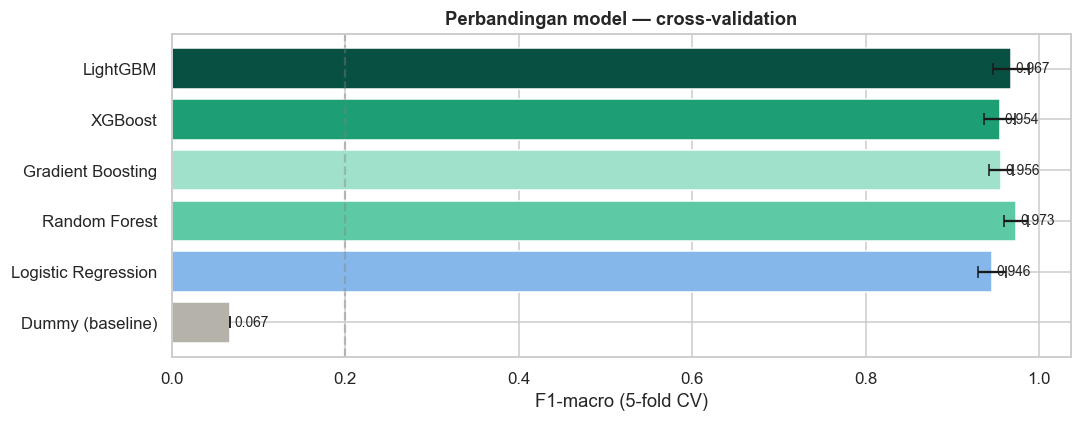


🏆  Model terbaik: Random Forest (F1-macro: 0.9728)


In [17]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Dummy (baseline)'    : DummyClassifier(strategy='most_frequent'),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost'             : XGBClassifier(n_estimators=200, eval_metric='mlogloss',
                                          random_state=RANDOM_STATE, verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           verbose=-1),
}

cv_results = {}
print('Menjalankan 5-fold CV untuk setiap model...')
print('─' * 52)

for name, model in candidates.items():
    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv=CV, scoring='f1_macro', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name:<26}  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

print('─' * 52)

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 4))
means  = [cv_results[n].mean() for n in candidates]
stds   = [cv_results[n].std()  for n in candidates]
colors_bar = ['#B4B2A9','#85B7EB','#5DCAA5','#9FE1CB','#1D9E75','#085041']
bars = ax.barh(list(candidates.keys()), means, xerr=stds,
               color=colors_bar, capsize=4, edgecolor='white')
ax.set_xlabel('F1-macro (5-fold CV)')
ax.set_title('Perbandingan model — cross-validation', fontweight='bold')
ax.axvline(x=0.2, color='gray', linestyle='--', alpha=0.4, label='random baseline')
for bar, val in zip(bars, means):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Pilih model terbaik
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\n🏆  Model terbaik: {best_name} (F1-macro: {cv_results[best_name].mean():.4f})')

In [18]:
# ── Train model terbaik & semua kandidat pada full training set ──
trained_models = {}
for name, model in candidates.items():
    model.fit(X_train_sc, y_train)
    trained_models[name] = model

print('✅  Semua model di-train pada full training set.')

✅  Semua model di-train pada full training set.


---
## Cell 7 — Fase 6: Evaluasi Model

Mengevaluasi performa setiap model pada **validation set** menggunakan:
- Accuracy
- F1-macro (rata-rata tidak tertimbang, cocok untuk kelas seimbang)
- Confusion matrix
- Classification report per kelas

In [19]:
print('Evaluasi pada VALIDATION SET')
print('═' * 55)

val_results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_val_sc)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='macro')
    val_results[name] = {'acc': acc, 'f1': f1, 'pred': y_pred}
    print(f'{name:<26}  Accuracy: {acc:.4f}  F1-macro: {f1:.4f}')

print('═' * 55)
best_val = max(val_results, key=lambda k: val_results[k]['f1'])
print(f'\n🏆  Best on val: {best_val}')

Evaluasi pada VALIDATION SET
═══════════════════════════════════════════════════════
Dummy (baseline)            Accuracy: 0.2000  F1-macro: 0.0667
Logistic Regression         Accuracy: 0.9733  F1-macro: 0.9732
Random Forest               Accuracy: 0.9933  F1-macro: 0.9933
Gradient Boosting           Accuracy: 0.9733  F1-macro: 0.9728
XGBoost                     Accuracy: 0.9733  F1-macro: 0.9731
LightGBM                    Accuracy: 0.9800  F1-macro: 0.9797
═══════════════════════════════════════════════════════

🏆  Best on val: Random Forest


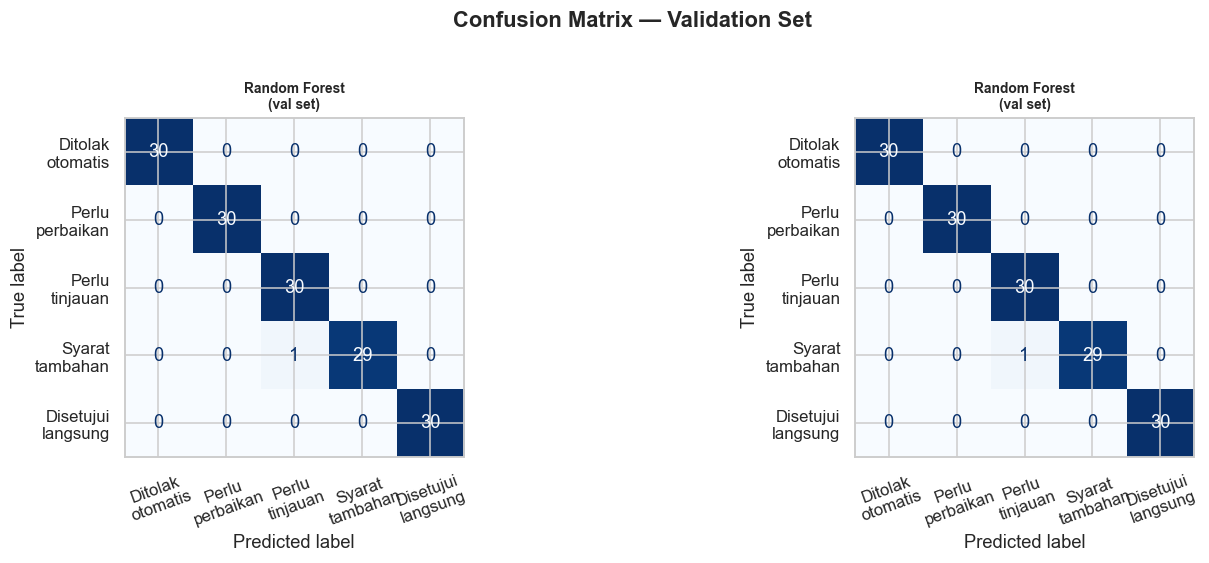


Classification Report — Random Forest

                                  precision    recall  f1-score   support

                Ditolak otomatis       1.00      1.00      1.00        30
          Perlu perbaikan profil       1.00      1.00      1.00        30
           Perlu tinjauan komite       0.97      1.00      0.98        30
Disetujui dengan syarat tambahan       1.00      0.97      0.98        30
              Disetujui langsung       1.00      1.00      1.00        30

                        accuracy                           0.99       150
                       macro avg       0.99      0.99      0.99       150
                    weighted avg       0.99      0.99      0.99       150



In [20]:
# ── Confusion matrix untuk model terbaik ────────────────────────
label_names_short = [
    'Ditolak\notomatis',
    'Perlu\nperbaikan',
    'Perlu\ntinjauan',
    'Syarat\ntambahan',
    'Disetujui\nlangsung'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, [best_name, best_val]):
    cm = confusion_matrix(y_val, val_results[name]['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names_short)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(val set)', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrix — Validation Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Classification report detail ────────────────────────────────
print(f'\nClassification Report — {best_val}\n')
print(classification_report(
    y_val, val_results[best_val]['pred'],
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
))

---
## Cell 8 — Fase 7: Hyperparameter Tuning

Melakukan `RandomizedSearchCV` pada model terbaik untuk mencari kombinasi hyperparameter optimal. Menggunakan **randomized search** (bukan grid search penuh) agar lebih efisien pada dataset kecil-menengah.

Setelah tuning, evaluasi ulang pada validation set dan bandingkan.

In [24]:
# ── Parameter grid untuk LightGBM / XGBoost / RandomForest ──────
# Sesuaikan secara otomatis berdasarkan model terbaik

param_grids = {
    'LightGBM': {
        'n_estimators'    : [100, 200, 400],
        'max_depth'       : [3, 5, 7, -1],
        'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'num_leaves'      : [15, 31, 63],
        'min_child_samples': [5, 10, 20],
        'subsample'       : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    },
    'XGBoost': {
        'n_estimators'    : [100, 200, 400],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'subsample'       : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'gamma'           : [0, 0.1, 0.5],
    },
    'Random Forest': {
        'n_estimators'    : [100, 200, 400],
        'max_depth'       : [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features'    : ['sqrt', 'log2', 0.5],
    },
    'Gradient Boosting': {
        'n_estimators'    : [100, 200],
        'max_depth'       : [3, 5],
        'learning_rate'   : [0.05, 0.1, 0.2],
        'subsample'       : [0.8, 1.0],
    },
}

# Gunakan model terbaik dari CV atau val — pilih yang relevan
TUNE_NAME = best_val  # bisa diganti manual, misal 'LightGBM'

if TUNE_NAME not in param_grids:
    print(f'{TUNE_NAME} tidak ada di param_grids, skip tuning.')
    best_tuned = trained_models[TUNE_NAME]
else:
    base_model = candidates[TUNE_NAME]
    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_grids[TUNE_NAME],
        n_iter=40,
        cv=CV,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    search.fit(X_train_sc, y_train)

    print(f'\nBest params: {search.best_params_}')
    print(f'Best CV F1-macro: {search.best_score_:.4f}')

    best_tuned = search.best_estimator_

    # Evaluasi model yang sudah di-tune pada val set
    y_pred_tuned = best_tuned.predict(X_val_sc)
    acc_t = accuracy_score(y_val, y_pred_tuned)
    f1_t  = f1_score(y_val, y_pred_tuned, average='macro')
    print(f'\nHasil setelah tuning pada val set:')
    print(f'  Accuracy : {acc_t:.4f}  (sebelumnya: {val_results[TUNE_NAME]["acc"]:.4f})')
    print(f'  F1-macro : {f1_t:.4f}  (sebelumnya: {val_results[TUNE_NAME]["f1"]:.4f})')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1-macro: 0.9800

Hasil setelah tuning pada val set:
  Accuracy : 0.9933  (sebelumnya: 0.9933)
  F1-macro : 0.9933  (sebelumnya: 0.9933)


---
## Cell 9 — Fase 8: Explainability dengan SHAP

SHAP (SHapley Additive exPlanations) menjelaskan **kontribusi setiap fitur** terhadap prediksi model.

Ini sangat penting untuk sistem kredit karena:
- Memastikan model tidak menggunakan fitur yang tidak relevan atau diskriminatif
- Memudahkan analis kredit memahami alasan rekomendasi model
- Diperlukan untuk kepatuhan regulasi (OJK mensyaratkan transparansi kredit)

Menghitung SHAP values (ini bisa memakan waktu beberapa detik)...


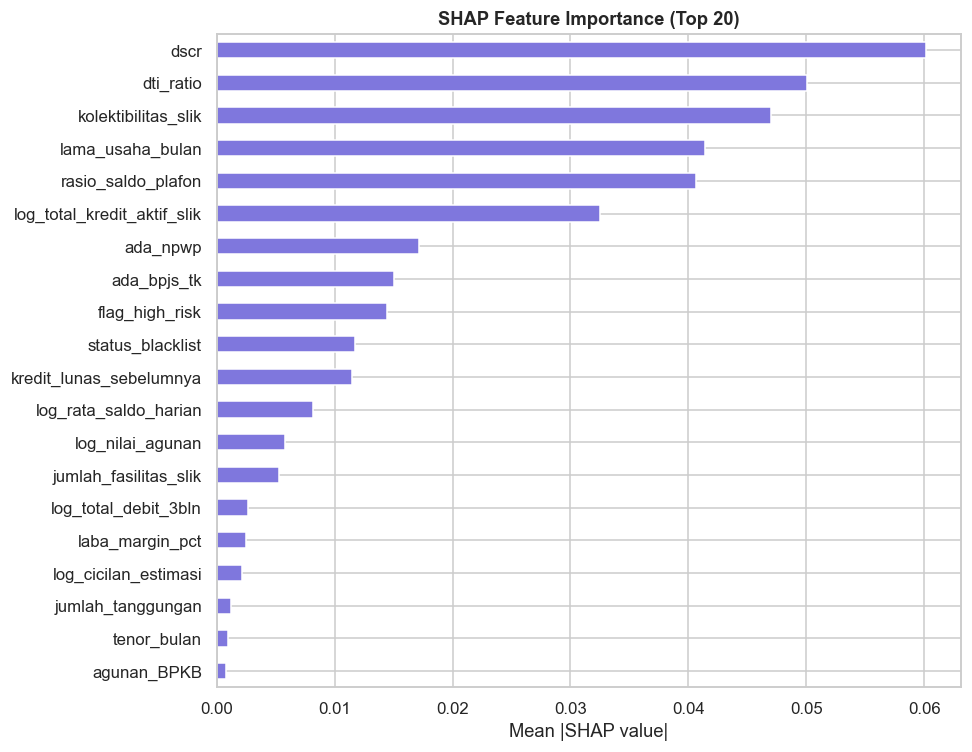


Top 10 fitur paling berpengaruh:
dscr                           0.0601
dti_ratio                      0.0500
kolektibilitas_slik            0.0470
lama_usaha_bulan               0.0414
rasio_saldo_plafon             0.0406
log_total_kredit_aktif_slik    0.0325
ada_npwp                       0.0172
ada_bpjs_tk                    0.0150
flag_high_risk                 0.0144
status_blacklist               0.0117


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print('Menghitung SHAP values (ini bisa memakan waktu beberapa detik)...')

# TreeExplainer bekerja langsung dengan tree-based models
explainer = shap.TreeExplainer(best_tuned)
shap_values = explainer.shap_values(X_train_sc)

# Menyeragamkan bentuk shap_values
if isinstance(shap_values, list):
    # Jika list (format SHAP lama untuk multi-class), rata-ratakan tiap class
    shap_mean = np.abs(np.array(shap_values)).mean(axis=0)
else:
    shap_mean = np.abs(shap_values)

# Ambil rata-rata dari seluruh observasi (axis=0)
importance_values = shap_mean.mean(axis=0)

# FIX: Cek apakah masih 2D (ada dimensi kelas/multi-output)
# Jika formatnya (jumlah_fitur, jumlah_kelas) -> (31, 5), kita rata-ratakan lagi antar kelasnya (axis=1)
if importance_values.ndim > 1:
    importance_values = importance_values.mean(axis=1)

# Feature importance berdasarkan SHAP
shap_importance = pd.Series(
    importance_values,
    index=FEATURE_NAMES[:importance_values.shape[0]]
).sort_values(ascending=False)

# Plot top 20 fitur
fig, ax = plt.subplots(figsize=(9, 7))
top20 = shap_importance.head(20)
top20[::-1].plot(kind='barh', ax=ax, color='#7F77DD', edgecolor='white')
ax.set_title('SHAP Feature Importance (Top 20)', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('\nTop 10 fitur paling berpengaruh:')
print(shap_importance.head(10).round(4).to_string())

---
## Cell 10 — Evaluasi Final pada Test Set

Test set hanya disentuh **satu kali** di sini — setelah semua keputusan tuning selesai.
Ini menghasilkan estimasi performa yang **tidak bias** terhadap proses development.

═══════════════════════════════════════════════════════
EVALUASI FINAL — TEST SET (hanya dibuka sekali)
═══════════════════════════════════════════════════════
Accuracy   : 0.9533
F1-macro   : 0.9529

                                  precision    recall  f1-score   support

                Ditolak otomatis       0.97      0.97      0.97        30
          Perlu perbaikan profil       0.97      0.93      0.95        30
           Perlu tinjauan komite       0.94      1.00      0.97        30
Disetujui dengan syarat tambahan       1.00      0.87      0.93        30
              Disetujui langsung       0.91      1.00      0.95        30

                        accuracy                           0.95       150
                       macro avg       0.96      0.95      0.95       150
                    weighted avg       0.96      0.95      0.95       150



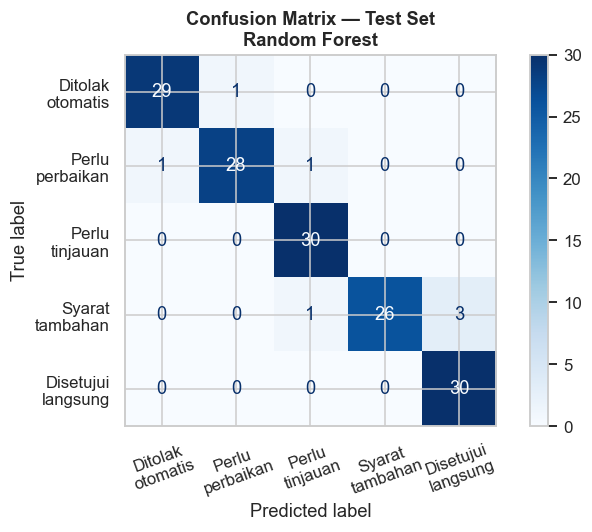

In [26]:
print('═' * 55)
print('EVALUASI FINAL — TEST SET (hanya dibuka sekali)')
print('═' * 55)

y_pred_test = best_tuned.predict(X_test_sc)
acc_final = accuracy_score(y_test, y_pred_test)
f1_final  = f1_score(y_test, y_pred_test, average='macro')

print(f'Accuracy   : {acc_final:.4f}')
print(f'F1-macro   : {f1_final:.4f}')
print()
print(classification_report(
    y_test, y_pred_test,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
))

# Confusion matrix test set
fig, ax = plt.subplots(figsize=(7, 5))
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm_test, display_labels=label_names_short)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Set\n{TUNE_NAME}', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## Cell 11 — Fase 9: Packaging & Deployment

Menyimpan semua artefak yang diperlukan untuk production:
- `model_kredit_umkm.pkl` — model yang sudah di-train
- `scaler_kredit_umkm.pkl` — scaler yang di-fit pada train set
- `model_metadata.json` — metadata: fitur, label mapping, performa

Lalu demo **inference function** — cara menggunakan model untuk satu pengajuan baru.

In [27]:
# ── Simpan artefak ────────────────────────────────────────────────
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(best_tuned, 'model_artifacts/model_kredit_umkm.pkl')
joblib.dump(scaler,     'model_artifacts/scaler_kredit_umkm.pkl')

metadata = {
    'model_name'    : TUNE_NAME,
    'feature_names' : FEATURE_NAMES,
    'label_map'     : LABEL_MAP,
    'label_names'   : LABEL_NAMES,
    'test_accuracy' : round(acc_final, 4),
    'test_f1_macro' : round(f1_final, 4),
    'n_train'       : len(X_train),
    'n_features'    : len(FEATURE_NAMES),
}
with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artefak tersimpan di folder model_artifacts/:')
for fname in os.listdir('model_artifacts'):
    fsize = os.path.getsize(f'model_artifacts/{fname}') / 1024
    print(f'  {fname}  ({fsize:.1f} KB)')

Artefak tersimpan di folder model_artifacts/:
  model_kredit_umkm.pkl  (1020.3 KB)
  model_metadata.json  (1.3 KB)
  scaler_kredit_umkm.pkl  (2.2 KB)


In [28]:
# ── Inference function — siap dipakai di production ──────────────

def predict_kelayakan(raw_input: dict) -> dict:
    """
    Menerima data satu pemohon (dict dengan kolom mentah),
    mengembalikan prediksi label dan probabilitas tiap kelas.

    Contoh input:
      raw_input = {
          'lama_usaha_bulan': 36, 'skala_usaha': 'kecil',
          'jenis_kur': 'kecil', 'tenor_bulan': 36,
          'kolektibilitas_slik': 1, 'status_blacklist': 'Tidak',
          'dti_ratio': 0.28, 'kredit_lunas_sebelumnya': 1,
          ... (semua kolom fitur mentah)
      }
    """
    # Load artefak
    model_loaded  = joblib.load('model_artifacts/model_kredit_umkm.pkl')
    scaler_loaded = joblib.load('model_artifacts/scaler_kredit_umkm.pkl')
    with open('model_artifacts/model_metadata.json') as f:
        meta = json.load(f)

    row = pd.DataFrame([raw_input])

    # Terapkan transformasi yang sama dengan training
    for col in ['ada_npwp','ada_bpjs_tk','status_blacklist','ada_agunan']:
        if col in row.columns:
            row[col] = (row[col].astype(str).str.lower() == 'ya').astype(int)

    row['skala_usaha_enc'] = row.get('skala_usaha', pd.Series(['mikro'])).map(skala_map).fillna(1)

    # Fitur turunan
    row['cicilan_estimasi'] = row['plafon_diajukan'] / row['tenor_bulan'] * 1.05
    row['dscr'] = row['rata_laba_bersih_bulanan'] / row['cicilan_estimasi'].replace(0, np.nan)
    row['rasio_saldo_plafon'] = row['rata_saldo_harian'] / row['plafon_diajukan'].replace(0, np.nan)
    row['laba_margin_pct'] = row['rata_laba_bersih_bulanan'] / row['total_pendapatan_bulanan'].replace(0, np.nan) * 100
    row['flag_high_risk'] = ((row['kolektibilitas_slik'] >= 3) | (row['status_blacklist'] == 1)).astype(int)
    for col in LOG_COLS:
        if col in row.columns:
            row[f'log_{col}'] = np.log1p(row[col])

    # Ambil hanya kolom yang dipakai model
    feat = meta['feature_names']
    for col in feat:
        if col not in row.columns:
            row[col] = 0
    row = row[feat].fillna(0)

    row_sc = scaler_loaded.transform(row)
    pred   = model_loaded.predict(row_sc)[0]
    proba  = model_loaded.predict_proba(row_sc)[0]

    label_names_map = {int(k): v for k, v in meta['label_names'].items()}
    return {
        'label'      : label_names_map[pred],
        'label_code' : int(pred),
        'probabilitas': {
            label_names_map[i]: round(float(p), 4)
            for i, p in enumerate(proba)
        }
    }


# ── Demo: prediksi satu contoh pemohon ──────────────────────────
contoh_pemohon = {
    'lama_usaha_bulan'         : 42,
    'skala_usaha'              : 'kecil',
    'jenis_kur'                : 'kecil',
    'tenor_bulan'              : 36,
    'jumlah_tanggungan'        : 2,
    'ada_npwp'                 : 'Ya',
    'ada_bpjs_tk'              : 'Ya',
    'total_pendapatan_bulanan' : 80_000_000,
    'hpp_bulanan'              : 45_000_000,
    'laba_kotor_bulanan'       : 35_000_000,
    'biaya_operasional_bulanan': 12_000_000,
    'rata_laba_bersih_bulanan' : 23_000_000,
    'rata_saldo_harian'        : 18_000_000,
    'total_kredit_3bln'        : 240_000_000,
    'total_debit_3bln'         : 190_000_000,
    'kolektibilitas_slik'      : 1,
    'total_kredit_aktif_slik'  : 15_000_000,
    'jumlah_fasilitas_slik'    : 1,
    'status_blacklist'         : 'Tidak',
    'kredit_lunas_sebelumnya'  : 1,
    'ada_agunan'               : 'Ya',
    'jenis_agunan'             : 'SHM',
    'nilai_agunan'             : 400_000_000,
    'rasio_agunan_terhadap_plafon': 1.6,
    'dti_ratio'                : 0.26,
    'plafon_diajukan'          : 250_000_000,
    'modal_usaha'              : 600_000_000,
    'skala_usaha_enc'          : 2,
}

hasil = predict_kelayakan(contoh_pemohon)

print('╔══════════════════════════════════════════════╗')
print('║  HASIL PREDIKSI KELAYAKAN KREDIT UMKM       ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Rekomendasi : {hasil["label"]:<30}║')
print(f'║  Kode label  : {hasil["label_code"]:<30}║')
print('╠══════════════════════════════════════════════╣')
print('║  Probabilitas per kelas:                    ║')
for lbl, prob in sorted(hasil['probabilitas'].items(), key=lambda x: -x[1]):
    bar = '█' * int(prob * 20)
    print(f'║  {lbl[:25]:<25} {prob:.3f} {bar}')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║  HASIL PREDIKSI KELAYAKAN KREDIT UMKM       ║
╠══════════════════════════════════════════════╣
║  Rekomendasi : Disetujui dengan syarat tambahan║
║  Kode label  : 3                             ║
╠══════════════════════════════════════════════╣
║  Probabilitas per kelas:                    ║
║  Disetujui dengan syarat t 0.746 ██████████████
║  Disetujui langsung        0.123 ██
║  Perlu tinjauan komite     0.111 ██
║  Perlu perbaikan profil    0.020 
║  Ditolak otomatis          0.000 
╚══════════════════════════════════════════════╝


---
## Cell 12 — Ringkasan & Langkah Selanjutnya

Pipeline selesai. Berikut ringkasan artefak yang dihasilkan dan rekomendasi pengembangan berikutnya.

In [29]:
print('╔══════════════════════════════════════════════════════╗')
print('║  RINGKASAN PIPELINE ML — KREDIT UMKM                ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Model        : {TUNE_NAME:<38}║')
print(f'║  Fitur        : {len(FEATURE_NAMES):<38}║')
print(f'║  Train rows   : {len(X_train):<38}║')
print(f'║  Accuracy     : {acc_final:.4f}{"":33}║')
print(f'║  F1-macro     : {f1_final:.4f}{"":33}║')
print('╠══════════════════════════════════════════════════════╣')
print('║  Artefak tersimpan:                                  ║')
print('║   model_artifacts/model_kredit_umkm.pkl             ║')
print('║   model_artifacts/scaler_kredit_umkm.pkl            ║')
print('║   model_artifacts/model_metadata.json               ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  Langkah selanjutnya:                                ║')
print('║   1. Kumpulkan data real dari sistem kredit          ║')
print('║   2. Retrain model dengan data aktual                ║')
print('║   3. Buat REST API (Flask/FastAPI) dari inference fn ║')
print('║   4. Tambahkan monitoring model drift (Evidently)    ║')
print('║   5. Jadwalkan retraining berkala (bulanan)          ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║  RINGKASAN PIPELINE ML — KREDIT UMKM                ║
╠══════════════════════════════════════════════════════╣
║  Model        : Random Forest                         ║
║  Fitur        : 31                                    ║
║  Train rows   : 700                                   ║
║  Accuracy     : 0.9533                                 ║
║  F1-macro     : 0.9529                                 ║
╠══════════════════════════════════════════════════════╣
║  Artefak tersimpan:                                  ║
║   model_artifacts/model_kredit_umkm.pkl             ║
║   model_artifacts/scaler_kredit_umkm.pkl            ║
║   model_artifacts/model_metadata.json               ║
╠══════════════════════════════════════════════════════╣
║  Langkah selanjutnya:                                ║
║   1. Kumpulkan data real dari sistem kredit          ║
║   2. Retrain model dengan data aktual                ║
║   3. Buat REST API (Flask/